<a href="https://colab.research.google.com/github/yasaswitaraja/SentinelNet/blob/main/notebooks/CICIDS2017.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


 Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

 2. Load Dataset

In [4]:
df = pd.read_csv("Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
print("Initial shape:", df.shape)
print(df.head())
# Clean column names by removing leading/trailing spaces
df.columns = df.columns.str.strip()


Initial shape: (225745, 79)
    Destination Port   Flow Duration   Total Fwd Packets  \
0              54865               3                   2   
1              55054             109                   1   
2              55055              52                   1   
3              46236              34                   1   
4              54863               3                   2   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        0                           12   
1                        1                            6   
2                        1                            6   
3                        1                            6   
4                        0                           12   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                       6   
1                             6                       6   
2                             6                       6   
3                   


3. Drop Unnecessary Columns


In [5]:
to_drop = ["Flow ID", "Source IP", "Destination IP", "Timestamp"]
df.drop([col for col in to_drop if col in df.columns], axis=1, inplace=True)

 4. Handle NaN & Infinite Values


In [6]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print("After cleaning:", df.shape)

After cleaning: (225711, 79)


 5. Encode Target Column

In [7]:
encoder = LabelEncoder()
df["Label"] = encoder.fit_transform(df["Label"])
print("Classes:", encoder.classes_)

Classes: ['BENIGN' 'DDoS']


6. Visualize Class Distribution

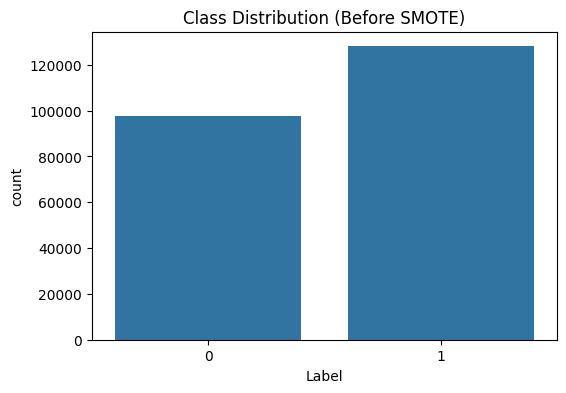

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["Label"])
plt.title("Class Distribution (Before SMOTE)")
plt.show()


7. Split Features & Target

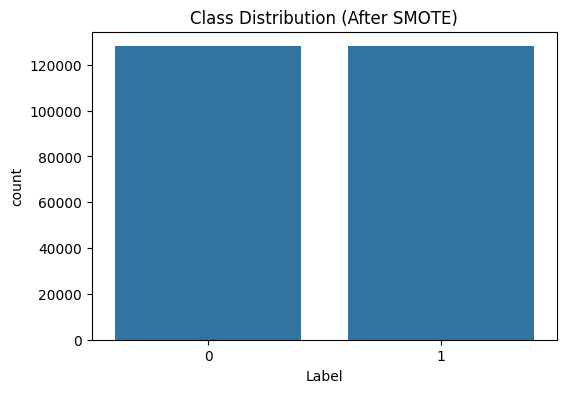

In [9]:
X = df.drop("Label", axis=1)
y = df["Label"]

# Handle class imbalance
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

plt.figure(figsize=(6,4))
sns.countplot(x=y_res)
plt.title("Class Distribution (After SMOTE)")
plt.show()

 8. Feature Scaling

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)

 9. Train-Test Split


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_res, test_size=0.2, random_state=42, stratify=y_res
)


 10. Dimensionality Reduction

In [12]:
pca = PCA(n_components=20, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


 11. Train Models

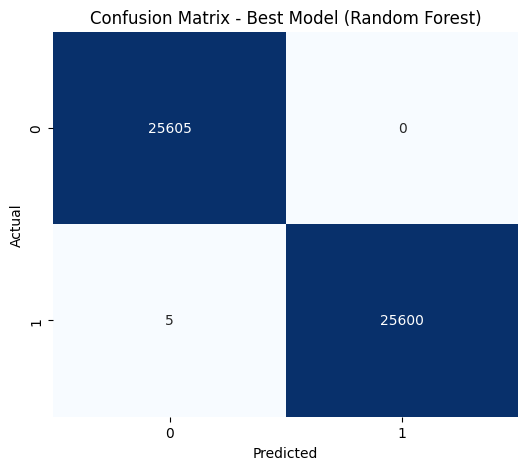

Model Comparison:
                      Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.998848   0.998848  0.998848  0.998848
Decision Tree        0.999844   0.999844  0.999844  0.999844
Random Forest        0.999902   0.999902  0.999902  0.999902


In [13]:

# 15. Train Models & Pick Best

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
best_model = None
best_f1 = 0
best_pred = None

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    results[name] = {
        "Accuracy": acc,
        "Precision": report['weighted avg']['precision'],
        "Recall": report['weighted avg']['recall'],
        "F1-Score": report['weighted avg']['f1-score']
    }

    # Track best model by F1-score
    if report['weighted avg']['f1-score'] > best_f1:
        best_f1 = report['weighted avg']['f1-score']
        best_model = name
        best_pred = y_pred


# 16. One Confusion Matrix for Best Model

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Confusion Matrix - Best Model ({best_model})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Show metrics table
results_df = pd.DataFrame(results).T
print("Model Comparison:\n", results_df)


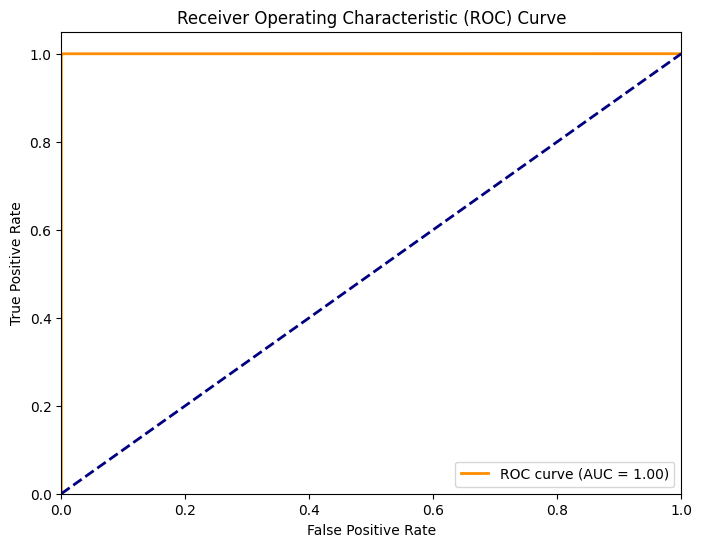

In [27]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming 'best_model' and 'models' dictionary are available from cell 3rKXdh8TQwD-
# and X_test, y_test, X_test_pca are available from previous cells.

if 'best_model' in globals() and 'models' in globals():
    clf = models[best_model]

    # Use PCA transformed test data if available, otherwise use scaled data
    if 'X_test_pca' in globals():
        y_score = clf.predict_proba(X_test_pca)[:, 1] # Get probabilities for the positive class
    else:
        y_score = clf.predict_proba(X_test)[:, 1] # Get probabilities for the positive class

    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

else:
    print("Best model or models dictionary not found. Please run the model training cell first.")

12. Compare Model Performance

                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.998848   0.998848  0.998848  0.998848
Decision Tree        0.999844   0.999844  0.999844  0.999844
Random Forest        0.999902   0.999902  0.999902  0.999902


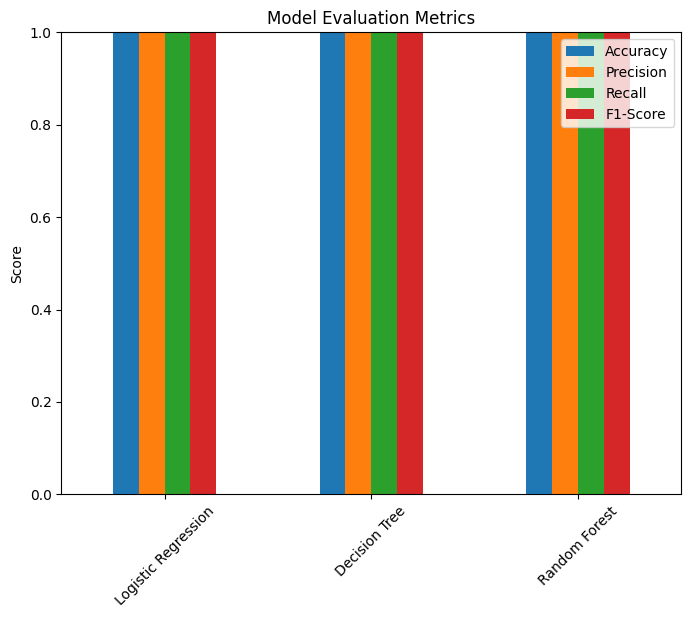

In [14]:


results_df = pd.DataFrame(results).T
print(results_df)

results_df.plot(kind="bar", figsize=(8,6))
plt.title("Model Evaluation Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()

Multiclass classification

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    if 'X_train_pca' in globals() and 'X_test_pca' in globals():
        model.fit(X_train_pca, y_train)
        y_pred = model.predict(X_test_pca)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)


    print(f"{name} trained. Evaluating...")

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)


    results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
print("\nModel Comparison:\n", results_df)


Training Logistic Regression...
Logistic Regression trained. Evaluating...

Training Decision Tree...
Decision Tree trained. Evaluating...

Training Random Forest...
Random Forest trained. Evaluating...

Training Gradient Boosting...
Gradient Boosting trained. Evaluating...

Model Comparison:
                  Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.992755   0.992822  0.992755  0.992755
1        Decision Tree  0.999688   0.999688  0.999688  0.999688
2        Random Forest  0.999785   0.999785  0.999785  0.999785
3    Gradient Boosting  0.999024   0.999024  0.999024  0.999024


In [31]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
from itertools import cycle



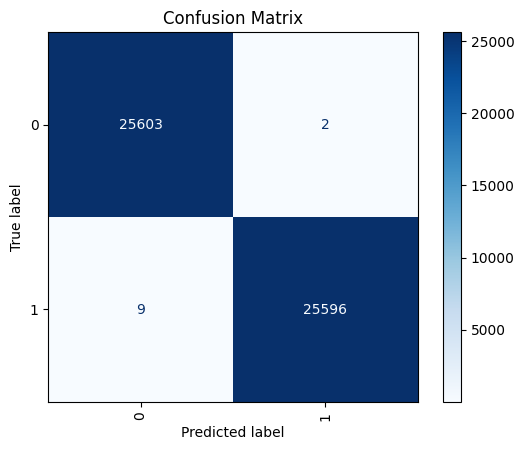

In [25]:
#  Confusion Matrix
display_labels = np.unique(y_test)
cm = confusion_matrix(y_test, y_pred, labels=display_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(xticks_rotation='vertical', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()